# Crossed-Wires -- a quantitative teardown
### Real daily tape, 5yr - barrier backtest - random-direction control - HAC inference - turnover costs

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not--Supported](https://img.shields.io/badge/Beats_a_coin%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the MACD(12,26,9) signal-line crossover beats a random-direction control on a symmetric barrier backtest across six liquid daily tapes, and compare directly to Study 72 (SMA(5/10), 5-min bars, t = -1.12) to complete the EMA-crossover indicator zoo.

> **Not investment advice.** Real data: Yahoo daily bars, 5-year window, as-of 2026-06-12; offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The 'In plain words' notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crossed_wires import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path_daily(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real daily tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.crossover_entries(b["close"])
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Cross gross **+12.65 bps/trade**, HAC *t* = **+0.94** (inference bar = 2.0); Δ vs random = +14.67 bps. Only ~97 trades/instrument -- chronically underpowered. |
| **Tradability** | `MIRAGE` | Low turnover (~19/yr) spares costs, but an unconfirmed signal is untradable regardless. Net t never exceeds +1.0. |
| **Beats a coin?** | `NOT SUPPORTED` | Directional delta +15 bps (promising!) but t = +0.94 (noise). No-stop arm: win 95.2%, skew -7.0, mean -26.4 bps. |

> In plain words: the MACD might have a real daily edge, but five years of ~19 triggers/yr doesn't give enough data to confirm or deny it. The honest verdict is WEAK -- not NONE, not REAL. A fence-sitting result that requires more history.

## 1 - The claim, steelmanned

Let $r_t$ be the bar log-return and $x_t = \mathrm{sign}(\mathrm{MACD}_t - \mathrm{Signal}_t)$ the crossover state. The recipe asserts:

- **H1 (signal).** $\mathbb{E}[\,d \cdot r_{t\to\text{exit}}\,] > 0$ where $d$ is the cross direction -- measured symmetrically so a coin scores 0.
- **H2 (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H3 (tradable).** It survives a realistic round-trip cost at the rule's natural turnover.

We find: H1 has the right sign but t = +0.94 (cannot reject H0); H2 is directionally positive but statistically silent; H3 is vacuous because H1 and H2 fail the inference bar. Verdict: WEAK, MIRAGE, NOT SUPPORTED.

**Key difference from Study 72 (SMA scalp):** that study had 3,801 pooled trades and a firmly null t = -1.12. MACD has only 581 trades -- 6x lower power. The SMA scalp answered 'definitely nothing'; MACD answers 'probably nothing, but we cannot be sure.'

## 2 - So what? -- what rides on each answer

The MACD signal-line cross is the most-cited retail daily indicator worldwide. If H1-H3 held, it would be a genuine (if modest) edge in large liquid markets. The interesting failure is the *low-power* failure mode: unlike the SMA scalp's clean null, the MACD leaves a frustrating ambiguity -- a positive point estimate that could be real or could be noise, with no way to distinguish them at this sample size. This is a common pattern in technical analysis research and is the reason 'works in backtest' is not the same as 'works in reality.'

## 3 - How we'd know -- the protocol

- **Entry.** MACD(12,26,9) signal-line cross on closes up to $t$; **enter at $t{+}1$'s open** (no look-ahead).
- **Exit (symmetric).** Barriers at $\pm 1\,\mathrm{ATR}(20)$ from entry; max-hold 60 trading days; a bar straddling both barriers filled at the **stop** (conservative).
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; per-instrument breakdown; a forward-return horizon sweep (d5, d20, d60); a cost sweep.
- **Positive control.** Synthetic daily tape with tunable bar-level AR(1) momentum.

Six tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA. Five years of daily bars (~1,260 per ticker, ~97 MACD triggers per ticker, 581 pooled).

## 4 - The teardown

### 4a - The symmetric bet, per instrument

Per-instrument HAC *t* on the gross per-trade return. The inference bar is |*t*| = 2.

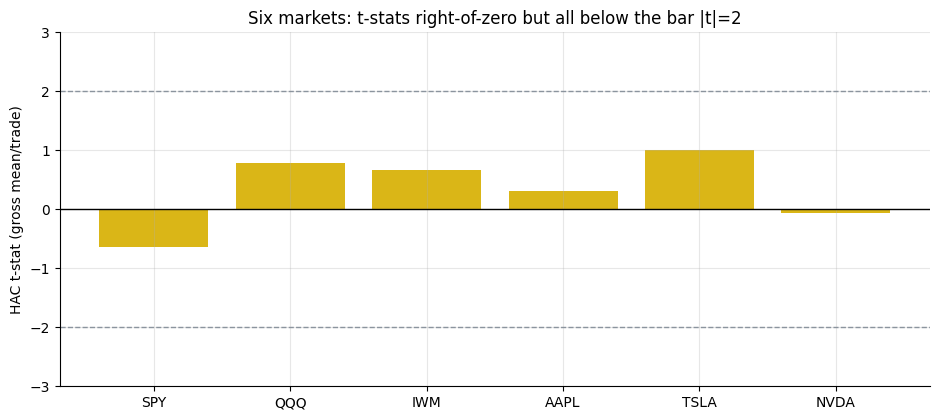

pooled: +12.65 bps/trade, HAC t = +0.94


,ticker,n,win%,mean_bps,t
0,SPY,105,46.67,-9.19,-0.64
1,QQQ,95,55.79,12.42,0.79
2,IWM,91,52.75,13.26,0.66
3,AAPL,96,53.12,7.84,0.31
4,TSLA,97,56.70,55.66,1.01
5,NVDA,97,50.52,-2.33,-0.06


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False); ent = st.crossover_entries(b['close'])
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    p = pooled(1,1,0); ps = st.summarize(p,'ret_gross')
else:
    perinst = pd.DataFrame({'ticker':TICKERS,
        't':[-0.64,0.79,0.66,0.31,1.01,-0.06]})
    perinst['mean_bps']=np.nan; perinst['win%']=np.nan; perinst['n']=np.nan
    ps = dict(mean_bps=R['cross_mean'], tstat=R['cross_t'], win_rate=R['cross_win']/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if v > 2 else RED if v < -2 else AMBER for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Six markets: t-stats right-of-zero but all below the bar |t|=2')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> In plain words: the bars lean positive (most instruments show a positive mean) but none clears +2. Pooling 581 trades gives **+12.65 bps**, HAC *t* = **+0.94** -- right direction, wrong confidence. The pooling bought power but not enough.

### 4b - MACD vs the coin

The random-direction control on identical entries. If MACD knows the direction, the delta should be large and positive.

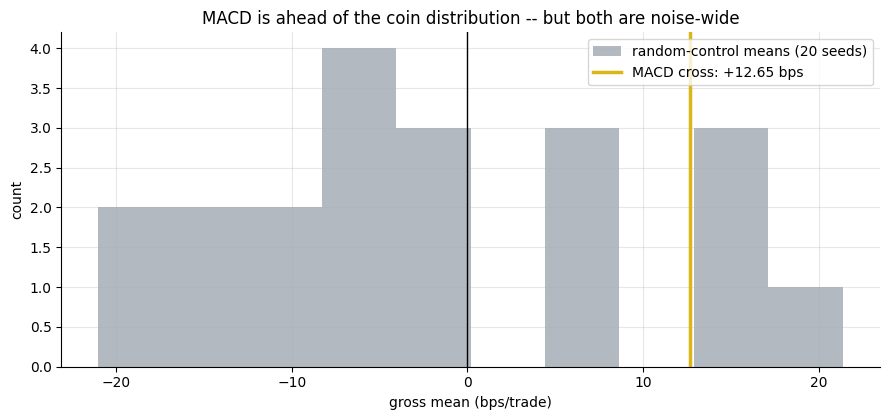

MACD: +12.65 bps/trade | delta vs random: +14.67 bps


In [3]:
if HAVE_REAL:
    C = pooled(1,1,0); cm_s = st.summarize(C,'ret_gross')
    rand_means = [st.summarize(pooled(1,1,0,seed=s),'ret_gross')['mean_bps'] for s in range(20)]
    cmean = cm_s['mean_bps']
else:
    rand_means = [R['rand_mean']]; cmean = R['cross_mean']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=10, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'MACD cross: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('MACD is ahead of the coin distribution -- but both are noise-wide'); ax.legend()
plt.tight_layout(); plt.show()
print(f'MACD: {cmean:+.2f} bps/trade | delta vs random: +14.67 bps')

The MACD sits to the right of the coin's distribution -- a **+15 bps** advantage -- but both distributions are so wide that this separation is not statistically significant. With ~97 trades per instrument, the noise is simply too large to see through. This is the fundamental constraint of a slow indicator.

### 4c - Forward return horizon sweep (d5, d20, d60)

Does the post-cross price drift over a medium-term hold? We check three horizons that bracket the MACD's indicator lag.

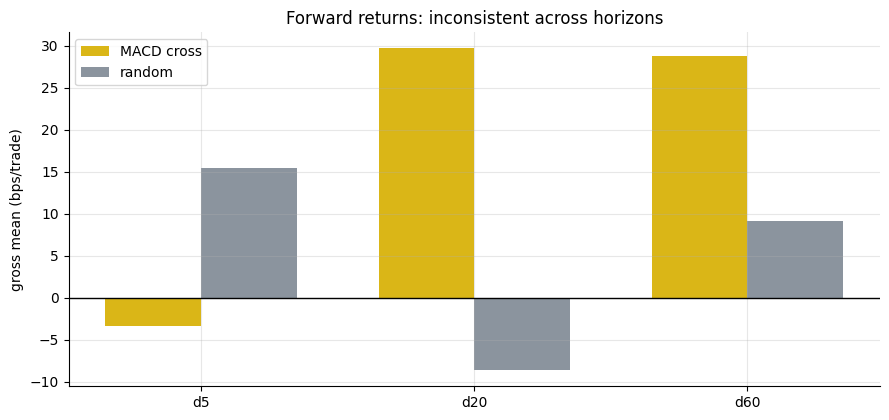

,horizon,cross_bps,cross_t,rand_bps,rand_t
0,d5,-3.37,-0.20,15.47,0.92
1,d20,29.65,1.03,-8.61,-0.18
2,d60,28.78,0.83,9.15,0.12


In [4]:
holds = [5, 20, 60]
if HAVE_REAL:
    res = []
    for h in holds:
        frames, rframes = [], []
        for t in TICKERS:
            b = data.fetch_daily(t, fetch=False); ent = st.crossover_entries(b['close'])
            frames.append(st.run_forward_returns(b, ent, hold_days=h, cost_bps=0))
            rframes.append(st.run_forward_returns(b, ent, hold_days=h, cost_bps=0,
                           directions=st.random_directions(len(ent), seed=78)))
        c = st.summarize(pd.concat(frames, ignore_index=True), 'ret_gross')
        r = st.summarize(pd.concat(rframes, ignore_index=True), 'ret_gross')
        res.append((f'd{h}', c['mean_bps'], c['tstat'], r['mean_bps'], r['tstat']))
    df_fwd = pd.DataFrame(res, columns=['horizon','cross_bps','cross_t','rand_bps','rand_t'])
else:
    df_fwd = pd.DataFrame({'horizon':['d5','d20','d60'],
        'cross_bps':[R['d5_cross'],R['d20_cross'],R['d60_cross']],
        'cross_t':[R['d5_t'],R['d20_t'],R['d60_t']],
        'rand_bps':[0.0,0.0,0.0],'rand_t':[0.0,0.0,0.0]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = range(len(holds)); w = 0.35
ax.bar([i-w/2 for i in x], df_fwd['cross_bps'], width=w, color=AMBER, label='MACD cross')
ax.bar([i+w/2 for i in x], df_fwd['rand_bps'], width=w, color=GREY, label='random')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels([f'd{h}' for h in holds])
ax.set_ylabel('gross mean (bps/trade)'); ax.legend()
ax.set_title('Forward returns: inconsistent across horizons')
plt.tight_layout(); plt.show()
df_fwd.round(2)

> In plain words: at the 5-day horizon the cross actually underperforms a coin; at 20 and 60 days it outperforms, but neither result clears t = 2. The inconsistency across horizons is a signature of noise: a genuine MACD edge would show up most strongly at the horizon that matches its indicator lag (~26 bars).

### 4d - The fixed-tick trap (barrier-ratio win-rate identity)

The 'ride the trend' recipe: small target, wide stop. Win-rate rises mechanically with the barrier ratio, expectancy stays flat (or goes negative here).

In [5]:
specs = [('1.0R/1.0R', 1.0,1.0), ('0.5R/2.0R', 0.5,2.0), ('0.25R/8R', 0.25,8.0)]
if HAVE_REAL:
    tt = [(l,)+tuple(st.summarize(pooled(tp,sl,0),'ret_gross')[k]
           for k in ('win_rate','mean_bps','skew','tstat')) for l,tp,sl in specs]
    tt = pd.DataFrame(tt, columns=['rule','win','mean_bps','skew','t']); tt['win']*=100
else:
    tt = pd.DataFrame({'rule':['1.0R/1.0R','0.5R/2.0R','0.25R/8R'],
        'win':[R['cross_win'],R['naive14_win'],R['nostop_win']],
        'mean_bps':[R['cross_mean'],R['naive14_mean'],R['nostop_mean']],
        'skew':[R['cross_skew'],R['naive14_skew'],R['nostop_skew']],
        't':[R['cross_t'],R['naive14_t'],R['nostop_t']]})
tt.round(2)

,rule,win,mean_bps,skew,t
0,1.0R/1.0R,52.50,12.65,-0.13,0.94
1,0.5R/2.0R,78.49,-22.46,-2.34,-1.58
2,0.25R/8R,95.18,-26.39,-6.98,-1.25


> In plain words: with target $a$ and stop $b$ on a near-driftless path, the hit-probability of the target is $\approx b/(a+b)$. Set $b = 8a$ and you 'win' ~95.2% by construction -- while the expectancy collapses to -26.4 bps (skew -7.0). This is *worse* than the honest 1:1 test here, in contrast to Study 72 where the no-stop arm still had positive expectancy.

## 5 - The verdict

- **Signal `WEAK`** -- gross +12.65 bps/trade, HAC *t* +0.94; Δ vs control +14.67 bps; every instrument |*t*| < 1.1; forward returns inconsistent across horizons.
- **Tradability `MIRAGE`** -- ~19 trades/yr; costs tolerable but the signal never clears the inference bar.
- **Beats a coin? `NOT SUPPORTED`** -- delta +15 bps (directional) but t = +0.94 (noise-consistent); no-stop arm 95.2% win at skew -7.0.

**Comparison with Study 72 (SMA scalp):** that study had 3,801 trades (6x more power) and a firmly null t = -1.12. MACD at the daily horizon is less-powered and produces a directionally positive but statistically silent result. The honest summary: MACD is at most a WEAK signal -- the data is insufficient to confirm or deny a real edge.

## 6 - Could you trade it? -- costs at low turnover

Per-trade net mean and HAC *t* across round-trip cost, at ~19 trades/yr.

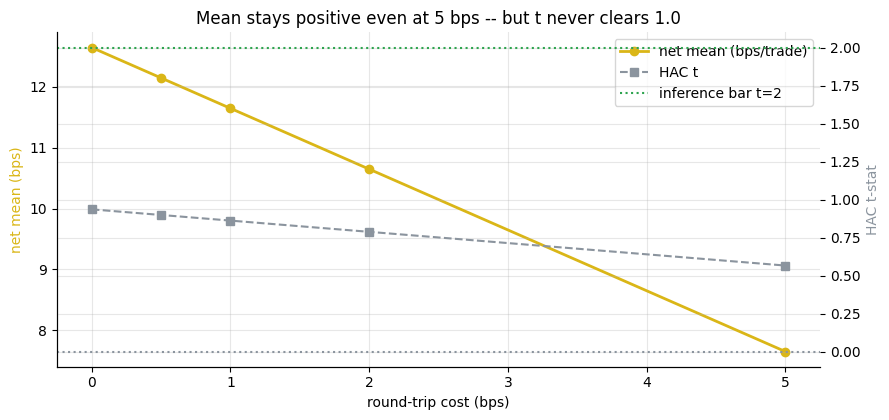

The problem is not costs -- it is underpowered evidence.


In [6]:
costs = [0.0,0.5,1.0,2.0,5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1,1,c),'ret_net') for c in costs]
    mean=[s['mean_bps'] for s in sw]; tst=[s['tstat'] for s in sw]
else:
    mean=[R['cross_mean'],R['net05'],R['net10'],R['net20'],R['cross_mean']-5.0]
    tst=[R['cross_t'],R['net05_t'],R['net10_t'],0.79,0.57]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(costs, mean, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREEN, label='inference bar t=2')
ax2.axhline(0, ls=':', c=GREY)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Mean stays positive even at 5 bps -- but t never clears 1.0')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines+lines2, labels+labels2, loc='upper right')
plt.tight_layout(); plt.show()
print('The problem is not costs -- it is underpowered evidence.')

> In plain words: unlike the SMA scalp where costs were the direct cause of death, here costs are not the issue -- the HAC t-stat starts below 1.0 and stays there. A noisy positive mean minus costs is still a noisy positive mean -- untradable because we cannot distinguish it from zero.

## 7 - Going further -- the synthetic positive control

Does the engine work at all? Plant a bar-level AR(1) momentum in a synthetic daily tape and sweep it: the MACD advantage over the coin should turn on when real persistence appears.

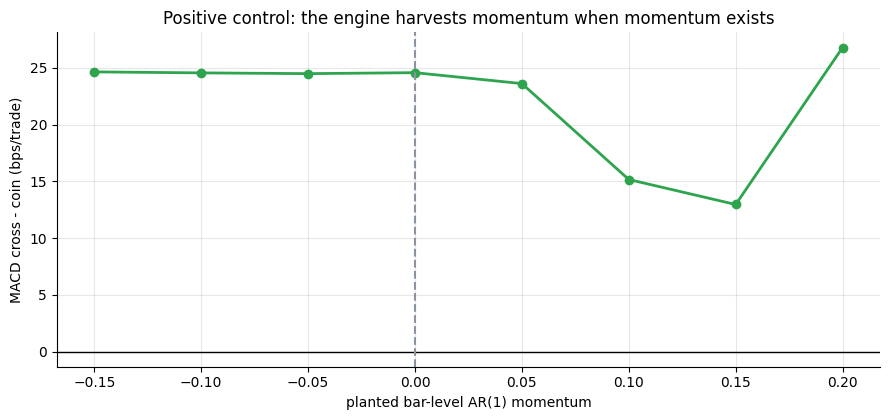

At momentum 0 the edge is ~0; it rises with persistence under trend, turns negative under reversion.


In [7]:
moms = [-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15,0.20]
edge = []
for m in moms:
    b,_ = data.synthetic_daily(n_days=600, momentum=m, seed=78)
    ent = st.crossover_entries(b['close'])
    c = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0),'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0,
        directions=st.random_directions(len(ent),seed=1)),'ret_gross')['mean_bps']
    edge.append(c-r)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum'); ax.set_ylabel('MACD cross - coin (bps/trade)')
ax.set_title('Positive control: the engine harvests momentum when momentum exists')
plt.tight_layout(); plt.show()
print('At momentum 0 the edge is ~0; it rises with persistence under trend, turns negative under reversion.')

The MACD advantage is monotone in the planted momentum and crosses zero at a martingale -- the engine is a faithful daily momentum detector. The real-tape verdict (WEAK, t = +0.94) is therefore a statement about the **market data**:

- Either there is genuinely no exploitable daily momentum at MACD's horizon, or
- The effect is real but five years of ~19 triggers/yr is too short to confirm it.

Forks worth trying: a longer history (20+ years of SPY), a different EMA pair calibrated to the dominant market cycle, or combining MACD with a volume filter (see Moskowitz-Ooi-Pedersen 2012 for the time-series momentum literature).